<!-- Cell 1 -->
# 05 — Evaluation

Evaluate the trained YOLOv11 checkpoint on the held-out **test** split: precision/recall, mAP@0.5, mAP@0.5:0.95, confusion matrix, per-class PR curves, model-variant comparison, and a qualitative prediction grid.

In [1]:
# Cell 2
# Install dependencies
%pip install -q "ultralytics==8.3.*" pandas numpy matplotlib seaborn pillow
# On a bare Linux box (no system libGL) OpenCV import can fail — if so, uncomment:
# !apt-get update -qq && apt-get install -y -qq libgl1
print("nb05 dependencies ready")

Note: you may need to restart the kernel to use updated packages.
nb05 dependencies ready


In [2]:
# Cell 3
%matplotlib inline

import re
from IPython.display import display as ipy_display

from ultralytics import YOLO
from pathlib import Path
import random
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image

In [3]:
# Cell 4
# ── Run selector ─────────────────────────────────────────────────────────────
# Set RUN_NAME to a specific folder name, or leave None to auto-select latest.
RUN_NAME = None   # e.g. '01_training_batch_2_00am_23_04_2026'

# ── Paths (derived — edit only RUN_NAME above) ────────────────────────────────
DATA_YAML         = Path('../data/dataset/data.yaml').resolve()
MODEL_OUTPUTS_DIR = Path('../model_outputs').resolve()

if RUN_NAME is None:
    _runs = sorted([
        d for d in MODEL_OUTPUTS_DIR.iterdir()
        if d.is_dir() and re.match(r'^\d+_training_batch_', d.name)
    ])
    assert _runs, f'No training runs found in {MODEL_OUTPUTS_DIR}'
    RUN_DIR  = _runs[-1]
    RUN_NAME = RUN_DIR.name
else:
    RUN_DIR = MODEL_OUTPUTS_DIR / RUN_NAME

WEIGHTS      = (RUN_DIR / 'weights' / 'best.pt').resolve()
TEST_IMG_DIR = Path('../data/dataset/images/test')

# ── Eval knobs ────────────────────────────────────────────────────────────────
CLASSES        = ['projector', 'whiteboard', 'fire_extinguisher', 'door_sign']
IMGSZ          = 640
CONF_THRESH    = 0.25
IOU_THRESH     = 0.5
N_QUALITATIVE  = 8
SEED           = 42

if torch.cuda.is_available():
    DEVICE = 0
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

random.seed(SEED)
assert WEIGHTS.exists(), f'Weights not found: {WEIGHTS} — train the model in notebook 04 first'
print('Run     :', RUN_NAME)
print('Weights :', WEIGHTS)
print('Device  :', DEVICE)

Run     : 04_training_batch_1_48am_24_04_2026
Weights : C:\Users\mitah\github_projects\ai_cv_project\model_outputs\04_training_batch_1_48am_24_04_2026\weights\best.pt
Device  : 0


<!-- Cell 5 -->
## 1. Run validation on the test split

In [4]:
# Cell 6
# ultralytics .val() — overall test-set metrics
# verbose=False suppresses noisy ANSI progress bars; plots=True saves PR_curve.png etc.
model = YOLO(WEIGHTS)
metrics = model.val(data=str(DATA_YAML), split='test', imgsz=IMGSZ,
                    conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE,
                    project=str(RUN_DIR / 'runs' / 'detect'), name='val',
                    verbose=False, plots=True)

print(f"{'Metric':<25} {'Value':>8}")
print("-" * 35)
print(f"{'mAP@0.5':<25} {metrics.box.map50:>8.4f}")
print(f"{'mAP@0.5:0.95':<25} {metrics.box.map:>8.4f}")
print(f"{'Precision (macro)':<25} {metrics.box.mp:>8.4f}")
print(f"{'Recall    (macro)':<25} {metrics.box.mr:>8.4f}")
print(f"\nResults saved to: {metrics.save_dir}")

Ultralytics 8.3.253  Python-3.13.12 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 85.328.6 MB/s, size: 32.5 KB)
val: Scanning C:\Users\mitah\github_projects\ai_cv_project\data\dataset\labels\test... 80 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 1.7Kit/s 0.0s
val: New cache created: C:\Users\mitah\github_projects\ai_cv_project\data\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.7s0.5s1s
                   all         80        102          1      0.861      0.933      0.796
Speed: 7.0ms preprocess, 9.1ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to C:\Users\mitah\github_projects\ai_cv_project\model_outputs\04_training_batch_1_48am_24_04_2026\runs\detect\val
Metric                       Value
---------------

<!-- Cell 7 -->
## 2. Per-class metrics

In [5]:
# Cell 8
# Per-class precision / recall / mAP table
p, r, ap50, ap = metrics.box.p, metrics.box.r, metrics.box.ap50, metrics.box.ap
per_class = pd.DataFrame({
    'class':       CLASSES,
    'precision':   np.round(p, 4),
    'recall':      np.round(r, 4),
    'mAP@0.5':     np.round(ap50, 4),
    'mAP@0.5:0.95': np.round(ap.mean(1) if ap.ndim > 1 else ap, 4),
})
per_class

,class,precision,recall,mAP@0.5,mAP@0.5:0.95
0,projector,1.0,0.8036,0.8964,0.7290
1,whiteboard,1.0,0.7625,0.8761,0.7767
2,fire_extinguisher,1.0,0.9565,0.9780,0.9045
3,door_sign,1.0,0.9224,0.9822,0.7733


<!-- Cell 9 -->
## 3. Confusion matrix (counts + column-normalized)

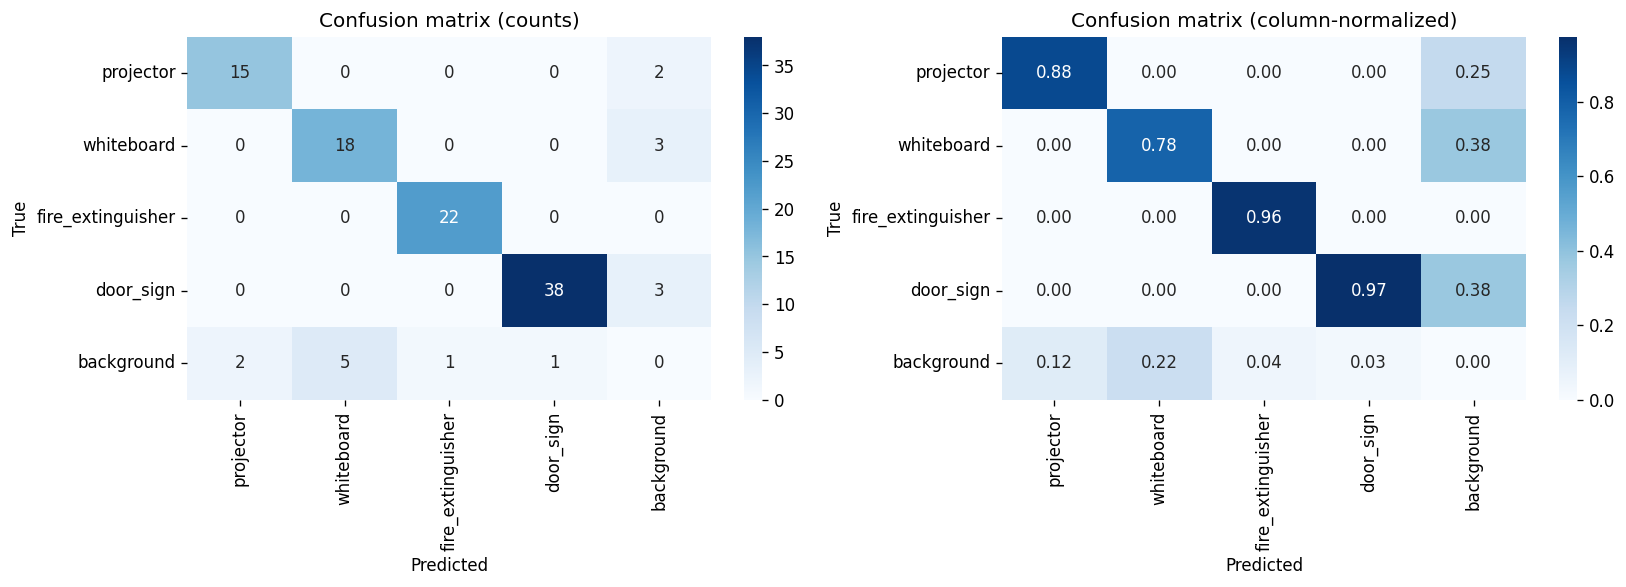

In [6]:
# Cell 10
import io
from IPython.display import Image as IPImage, display as ipy_display

cm = metrics.confusion_matrix.matrix
labels = CLASSES + ['background']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=labels, yticklabels=labels, cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion matrix (counts)'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')

cm_norm = cm / cm.sum(axis=0, keepdims=True).clip(min=1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion matrix (column-normalized)'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0)
plt.close(fig)
ipy_display(IPImage(data=buf.getvalue()))

<!-- Cell 11 -->
## 4. Per-class PR curves
Ultralytics writes `PR_curve.png` under the val run directory.

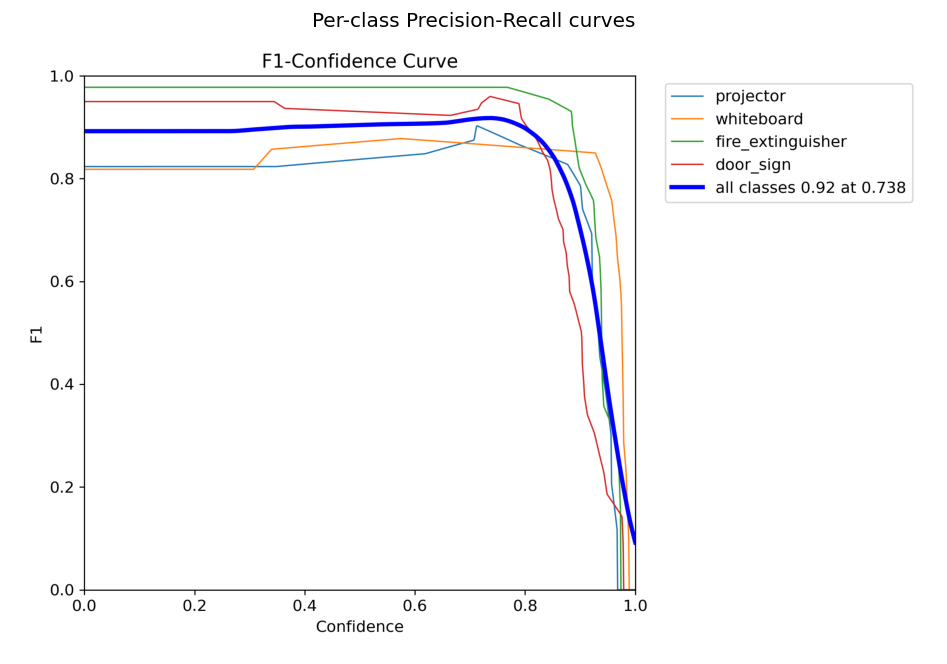

In [7]:
# Cell 12
import io
from IPython.display import Image as IPImage, display as ipy_display

save_dir = Path(metrics.save_dir)
pr_img = save_dir / 'PR_curve.png'
if not pr_img.exists():
    candidates = sorted(save_dir.glob('*curve*.png')) + sorted(save_dir.glob('*PR*.png'))
    pr_img = candidates[0] if candidates else None

if pr_img and pr_img.exists():
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(Image.open(pr_img))
    ax.set_title('Per-class Precision-Recall curves')
    ax.axis('off')
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    ipy_display(IPImage(data=buf.getvalue()))
else:
    print(f'No PR curve PNG found in {save_dir}')
    print('Available files:', [p.name for p in save_dir.glob('*.png')])

<!-- Cell 13 -->
## 5. Model-variant comparison
Re-run cells 5–7 after training each variant (notebook 04 → change `CFG['model']`) and fill this table.

In [8]:
# Cell 14
# Auto-detect the trained variant from parameter count, then populate the correct row
n_params_m = sum(p.numel() for p in model.model.parameters()) / 1e6
if n_params_m < 5:
    trained_variant = 'yolo11n'
elif n_params_m < 15:
    trained_variant = 'yolo11s'
else:
    trained_variant = 'yolo11m'

print(f"Detected variant: {trained_variant} ({n_params_m:.1f}M params)")

comparison = pd.DataFrame([
    {'variant': 'yolo11n', 'params_M': 2.6,  'mAP@0.5': None, 'mAP@0.5:0.95': None, 'latency_ms': None},
    {'variant': 'yolo11s', 'params_M': 9.4,  'mAP@0.5': None, 'mAP@0.5:0.95': None, 'latency_ms': None},
    {'variant': 'yolo11m', 'params_M': 20.0, 'mAP@0.5': None, 'mAP@0.5:0.95': None, 'latency_ms': None},
])
mask = comparison['variant'] == trained_variant
comparison.loc[mask, 'mAP@0.5']        = round(metrics.box.map50, 4)
comparison.loc[mask, 'mAP@0.5:0.95']   = round(metrics.box.map,   4)
comparison

Detected variant: yolo11n (2.6M params)


,variant,params_M,mAP@0.5,mAP@0.5:0.95,latency_ms
0,yolo11n,2.6,0.9332,0.7959,None
1,yolo11s,9.4,None,None,None
2,yolo11m,20.0,None,None,None


<!-- Cell 15 -->
## 6. Qualitative prediction grid

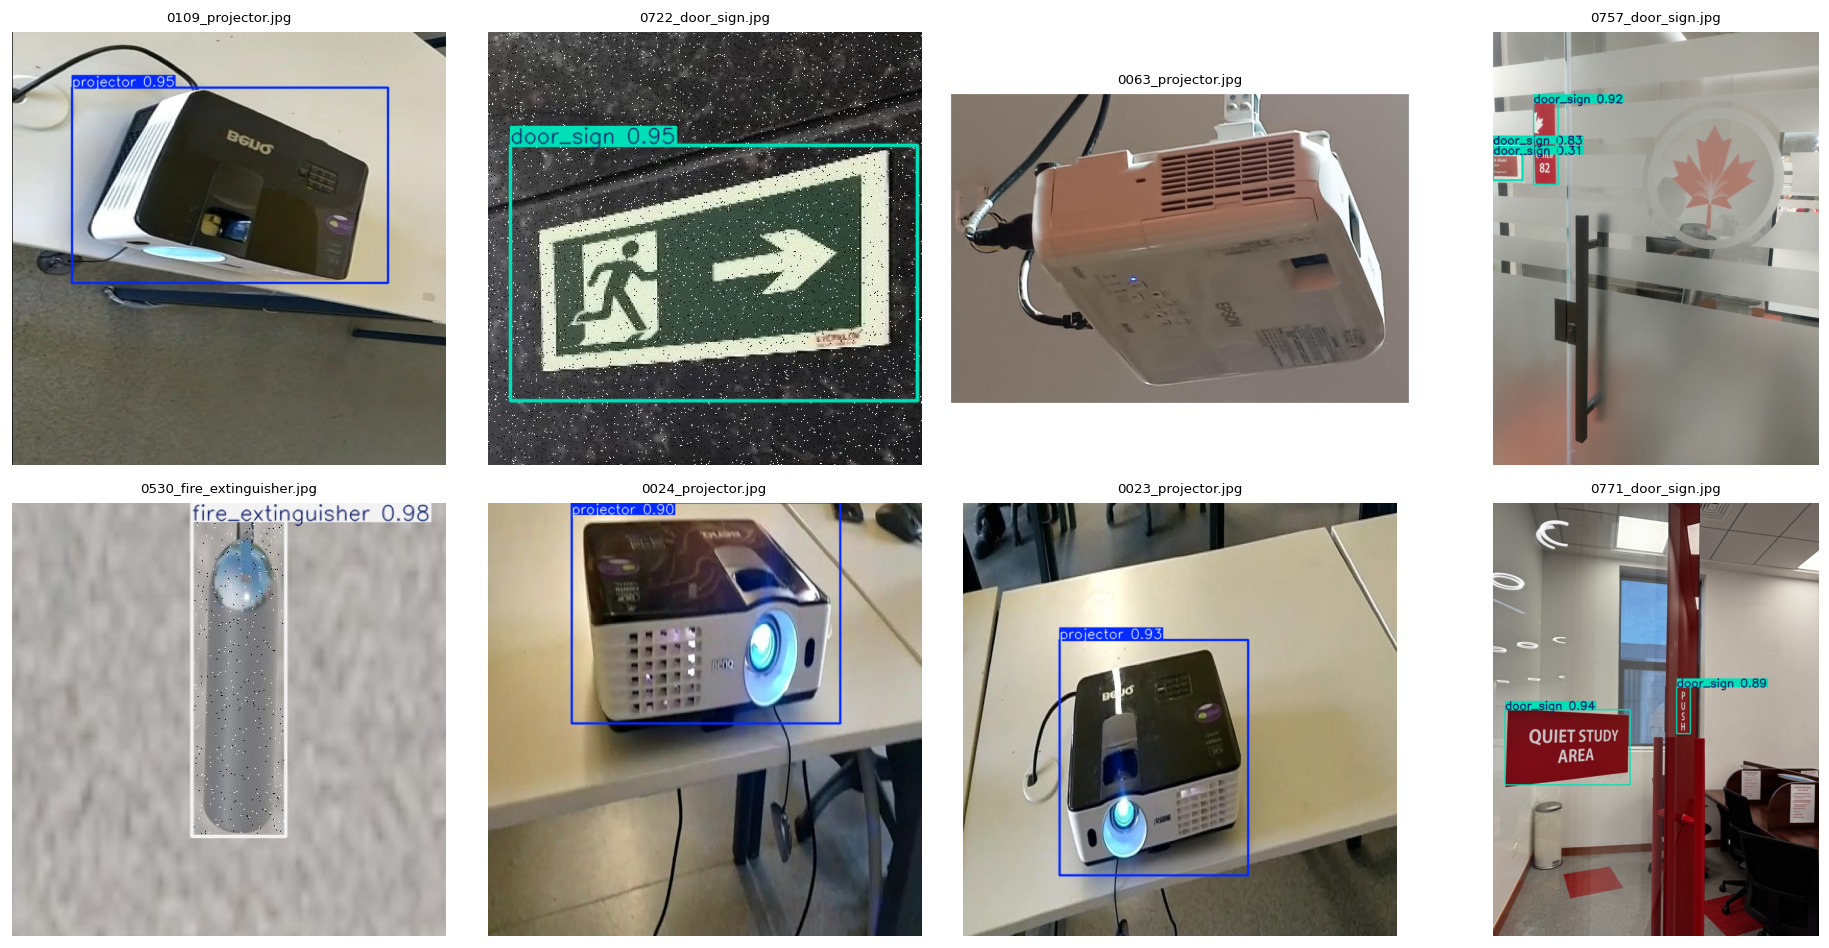

In [9]:
# Cell 16
import io
from IPython.display import Image as IPImage, display as ipy_display

test_imgs = sorted(TEST_IMG_DIR.glob('*.jpg'))
sample = random.sample(test_imgs, min(N_QUALITATIVE, len(test_imgs)))
preds = model.predict(source=[str(p) for p in sample], imgsz=IMGSZ,
                      conf=CONF_THRESH, device=DEVICE, verbose=False)

cols = 4
rows = (len(preds) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
for ax, r in zip(axes.flatten(), preds):
    ax.imshow(r.plot()[:, :, ::-1])  # BGR -> RGB
    ax.set_title(Path(r.path).name, fontsize=8)
    ax.axis('off')
for ax in axes.flatten()[len(preds):]:
    ax.axis('off')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0)
plt.close(fig)
ipy_display(IPImage(data=buf.getvalue()))

<!-- Cell 17 -->
### Reporting checklist
- [ ] Per-class precision / recall / mAP table filled with real numbers
- [ ] Confusion matrix inspected — identify dominant confusion pairs
- [ ] PR curves attached
- [ ] Variant comparison table completed for `yolo11n`, `yolo11s`, `yolo11m`
- [ ] N_QUALITATIVE-image grid included in the report